# Notebook 2 SOLUTIONS: Bayesian Quadrature on Alanine Dipeptide

In the previous notebook we used **Bayesian Optimization (BO)** to find
where the force is zero  i.e. the minima/maxima of the free energy surface.

In this notebook we use **Bayesian Quadrature (BUQ)** to do something more
ambitious: reconstruct the **entire free energy surface** A(phi, psi) by integrating
the mean force over both dihedral angles.

### What is the difference?

| | Bayesian Optimization | Bayesian Quadrature |
|---|---|---|
| **Goal** | Find minimum of f(x) | Compute integral of f(x) |
| **Surrogate** | GP on \|force(phi)\| | GP on force(phi, psi) directly |
| **Acquisition** | Reduce uncertainty near minimum | Reduce uncertainty of integral |
| **Output** | Best (phi, psi) found | F(phi, psi) + error bars |

### What you will learn
- How BUQ places new simulation points to reduce **integral uncertainty** in 2D
- How kernel choice and hyperparameters affect the GP over the force
- How the IVR acquisition function differs from EI/LCB
- How sampling patterns differ between BO (notebook 1) and BUQ (this notebook)

For more information, check out our paper: https://arxiv.org/abs/2601.08783


> **Note:** We use `AdipepFromGrid`, which wraps the same metadynamics data
> as notebook 1 but exposes both dihedral angles (phi, psi), so you can directly
> compare sampling strategies.

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from buq import BQConfig, BayesianQuadratureRunner
from buq.sample_systems import Adipep2DFromGrid

## 1. The system: alanine dipeptide (phi, psi)

`AdipepFromGrid` wraps the precomputed metadynamics data.
It exposes the mean force f(phi, psi) = dA/d(phi, psi) via `system.get_force(x)`.

Let's first look at what the system gives us.

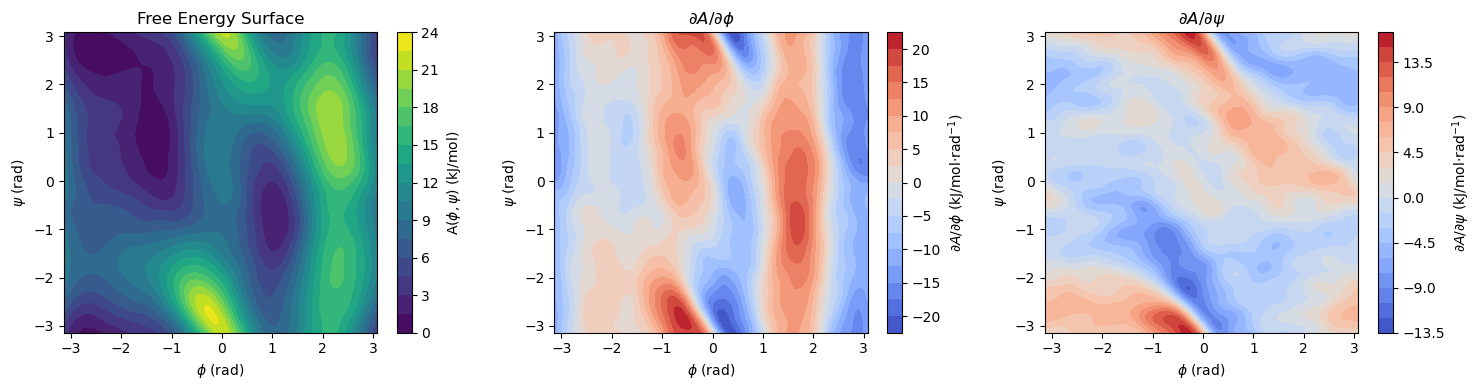

In [2]:
system = Adipep2DFromGrid()

# Evaluate FES on a dense grid for reference
dat = np.loadtxt("fes_adipep_phi_psi.dat")
phi_flat = dat[:, 0]
psi_flat = dat[:, 1]
fes_flat = dat[:, 2]
dAdphi_flat = dat[:, 3]   
dAdpsi_flat = dat[:, 4]
# Reconstruct the 2D grid
phi_vals = np.unique(phi_flat)
psi_vals = np.unique(psi_flat)
PHI, PSI = np.meshgrid(phi_vals, psi_vals)
FES_ref = fes_flat.reshape(len(phi_vals), len(psi_vals))
dAdphi    = dAdphi_flat.reshape(len(psi_vals), len(phi_vals))
dAdpsi    = dAdpsi_flat.reshape(len(psi_vals), len(phi_vals))
FES_ref -= np.min(FES_ref)


# --- Plot FES + gradients ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# FES
cf0 = axes[0].contourf(PHI, PSI, FES_ref, levels=20, cmap="viridis")
plt.colorbar(cf0, ax=axes[0], label=r"A($\phi, \psi$) (kJ/mol)")
axes[0].set_xlabel(r"$\phi$ (rad)")
axes[0].set_ylabel(r"$\psi$ (rad)")
axes[0].set_title("Free Energy Surface")

# ∂A/∂φ
cf1 = axes[1].contourf(PHI, PSI, dAdphi, levels=20, cmap="coolwarm")
plt.colorbar(cf1, ax=axes[1], label=r"$\partial A / \partial \phi$ (kJ/mol·rad$^{-1}$)")
axes[1].set_xlabel(r"$\phi$ (rad)")
axes[1].set_ylabel(r"$\psi$ (rad)")
axes[1].set_title(r"$\partial A / \partial \phi$")

# ∂A/∂ψ
cf2 = axes[2].contourf(PHI, PSI, dAdpsi, levels=20, cmap="coolwarm")
plt.colorbar(cf2, ax=axes[2], label=r"$\partial A / \partial \psi$ (kJ/mol·rad$^{-1}$)")
axes[2].set_xlabel(r"$\phi$ (rad)")
axes[2].set_ylabel(r"$\psi$ (rad)")
axes[2].set_title(r"$\partial A / \partial \psi$")

plt.tight_layout()
plt.show()

## 2. Configure BUQ

`BQConfig` controls the GP kernel and the BUQ loop.

Key parameters:
- `kernel_type`: shape of the GP covariance -- `"Matern12"`, `"Matern32"`, `"Matern52"`, `"RBF"`
- `lengthscale`: ARD lengthscales for each dimension (phi and psi), controls how quickly the GP varies
- `noise`: assumed observation noise (white kernel)
- `acq_function`: `"IVR"` (Integral Variance Reduction), `"US"` (Uncertainty Sampling), `"MI"` (Mutual Information)
- `grid_size_2d`: resolution of the internal (phi, psi) grid -- in 2D this matters more, since a high resolution grid significantly slows down integral computation
- `use_mini` / `fast_mini`: enable L-BFGS-B refinement for the 2D integration step

### TODO: try changing these settings and see what happens!
- `kernel_type`
- `lengthscale`
- `noise`

In [3]:
# --- Settings: change these! ---
kernel_type = "Matern32"
lengthscale = np.array([0.75, 0.75])   # one per dimension (ARD)
noise       = 1e-6
# --------------------------------

config = BQConfig(
    kernel_type=kernel_type,
    lengthscale=lengthscale,
    noise=noise,
    variance=1.0,
    acq_function="IVR",
    grid_size_2d=(40, 40),
    use_mini=True,
    fast_mini=True,
)

## 3. Initialize the runner

We start with a small set of initial points where the force has already been
evaluated. The runner fits an initial GP to these observations.

### TODO: try different initial point placements
- What happens if all initial points are clustered in one region?

Running initial simulation at x = [-1.50796447  1.19380521]
Running initial simulation at x = [ 0.87964594 -0.87964594]
# Integrating             - Simpson's rule 
# Integration error:        0.57

Initial points:
 [[-1.50796447  1.19380521]
 [ 0.87964594 -0.87964594]]
Initial FES shape (nx, ny): (40, 40)


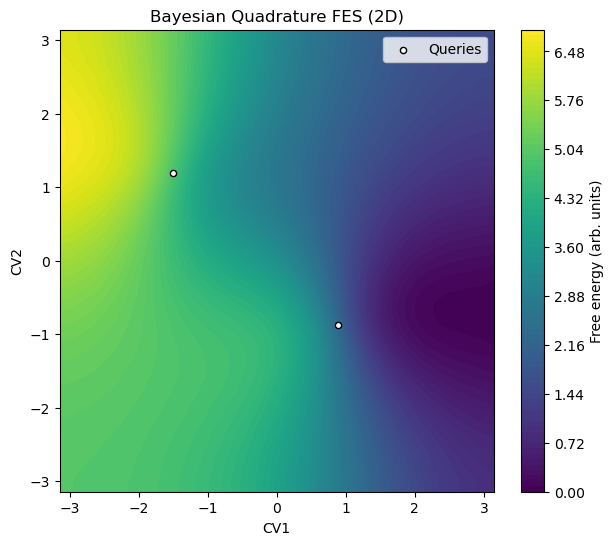

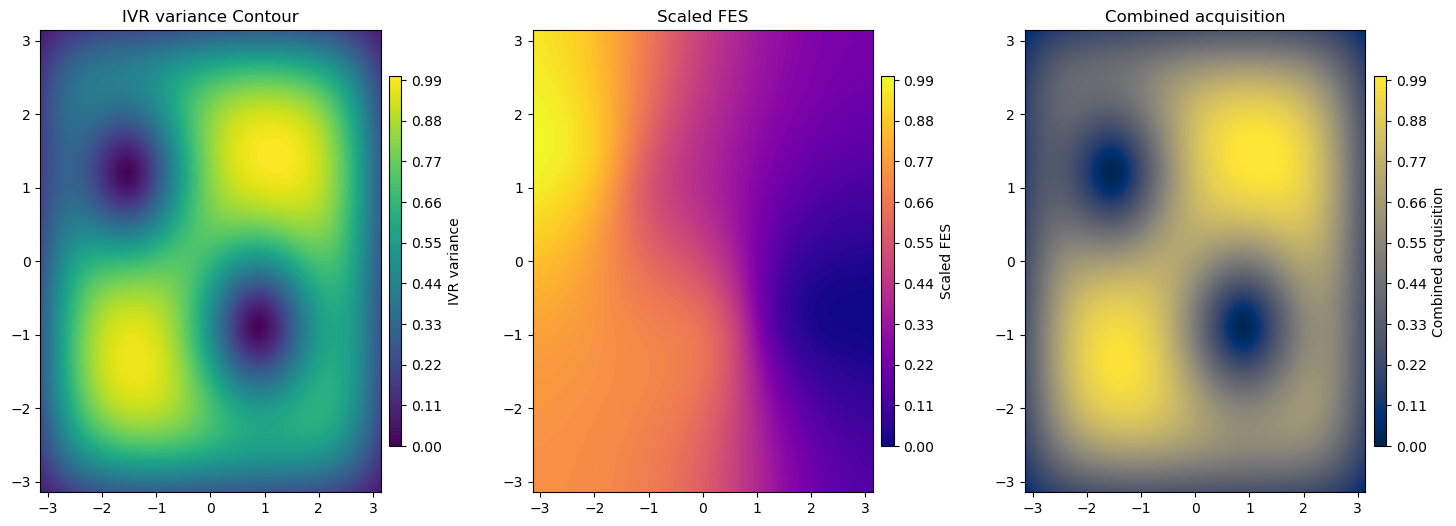

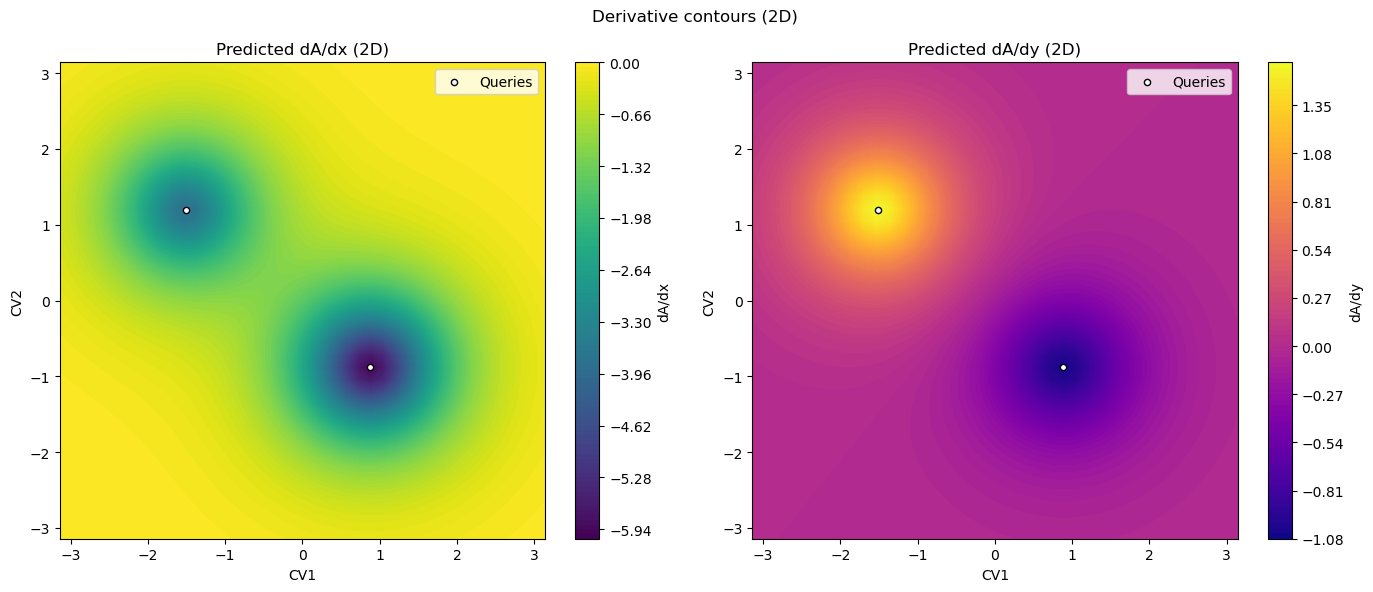

In [4]:
# --- Settings: change these! ---
initial_points = np.array([[-1.507964474, 1.193805208 ],  [0.879645943, -0.879645943]])
# --------------------------------
    
runner = BayesianQuadratureRunner(system, config)
runner.initialize(initial_points)

print("Initial points:\n", initial_points)
print("Initial FES shape (nx, ny):", runner.current_fes_2d.shape)

# Plot initial state
runner.plot_fes(show=True)
runner.plot_acq(show=True, full=True)
runner.plot_derivatives(show=True)

**Questions:**
- Where does the acquisition function suggest sampling next? Why?
- How does the initial FES estimate compare to the reference?

## 4. The BUQ loop

At each step the runner:
1. Evaluates the IVR acquisition function on the (phi, psi) grid
2. Picks the (phi, psi) that maximally reduces integral variance
3. Queries the force at that point (`system.get_force`)
4. Updates the GP posterior and recomputes the 2D FES

The acquisition is a weighted combination:

$$\text{acq}(\phi, \psi) = (1 - w_\text{fes}) \cdot \text{IVR}(\phi, \psi) - w_\text{fes} \cdot \hat{F}(\phi, \psi)$$

- `weight_var=1, weight_fes=0`: pure IVR -- reduces integral variance uniformly
- `weight_fes > 0`: biases sampling toward high free energy regions (exploitation)

### TODO: try changing the weights and number of steps

Running initial simulation at x = [-1.50796447  1.19380521]
Running initial simulation at x = [ 0.87964594 -0.87964594]
# Integrating             - Simpson's rule 
# Integration error:        0.57


--- Step 1/5 ---
Selected next point: [1.20830487 1.36941218]
# Integrating             - Simpson's rule 
# Integration error:        1.85



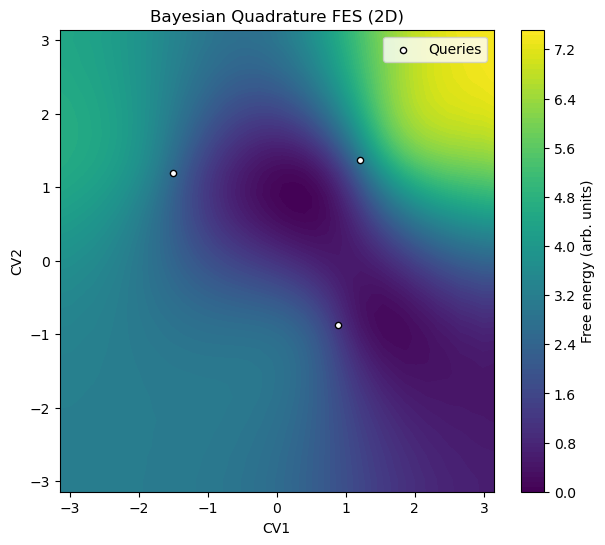

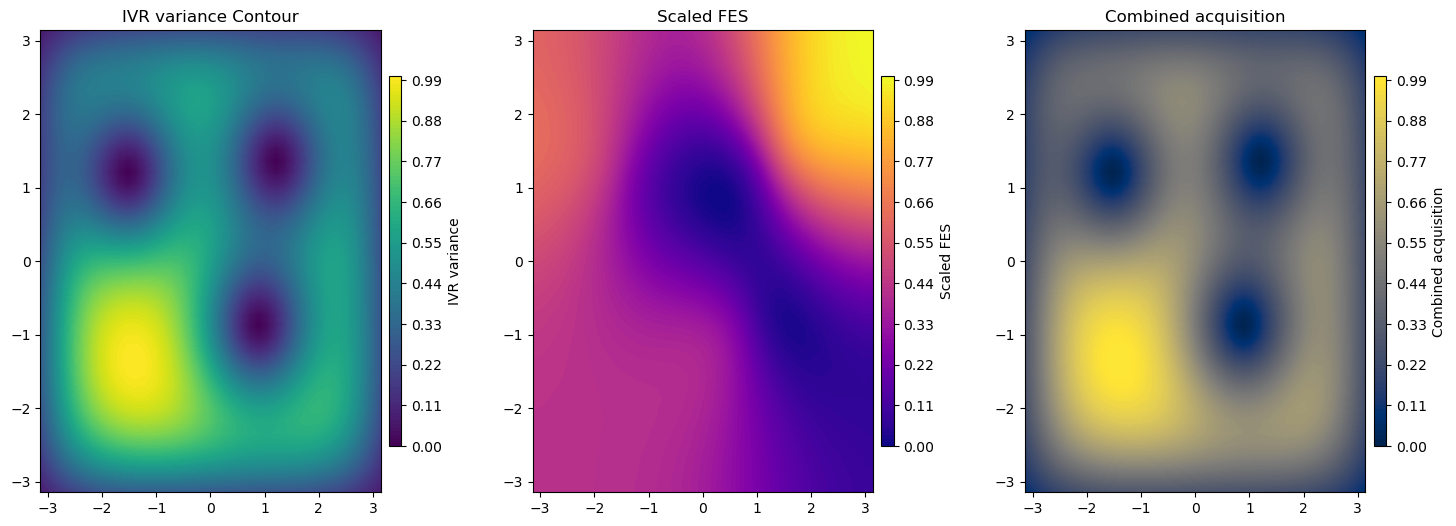


--- Step 2/5 ---
Selected next point: [-1.36941218 -1.36941218]
# Integrating             - Simpson's rule 
# Integration error:        1.93



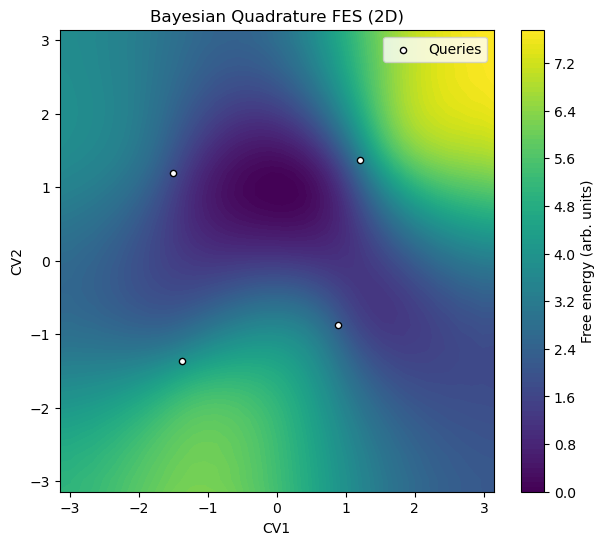

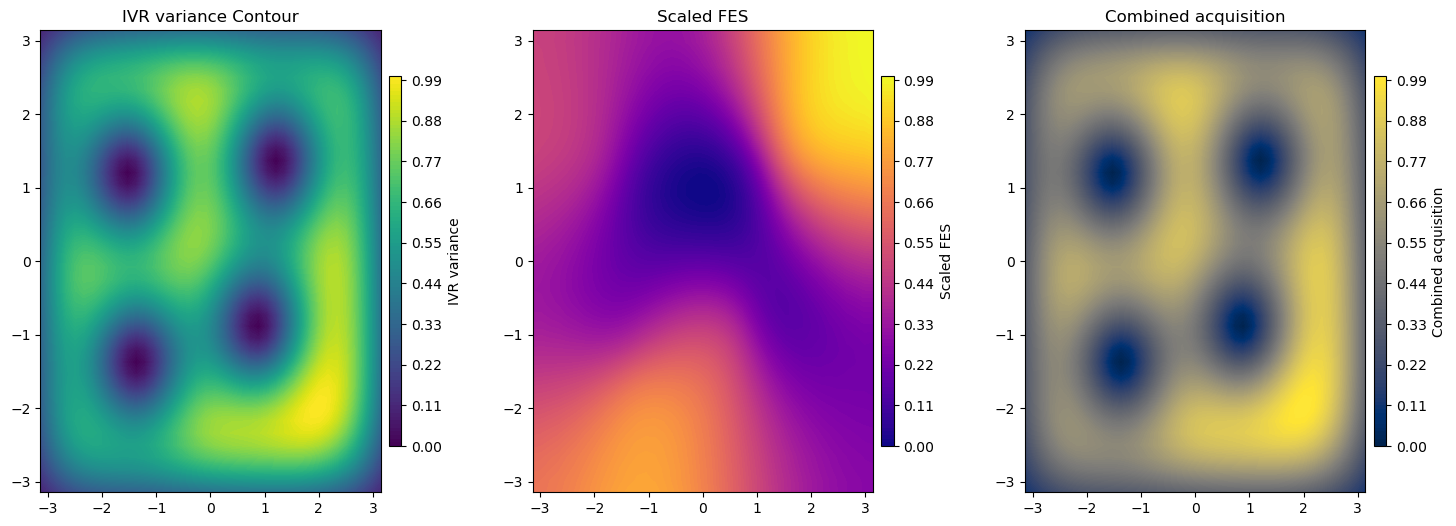


--- Step 3/5 ---
Selected next point: [ 2.01384144 -2.01384144]
# Integrating             - Simpson's rule 
# Integration error:        2.42



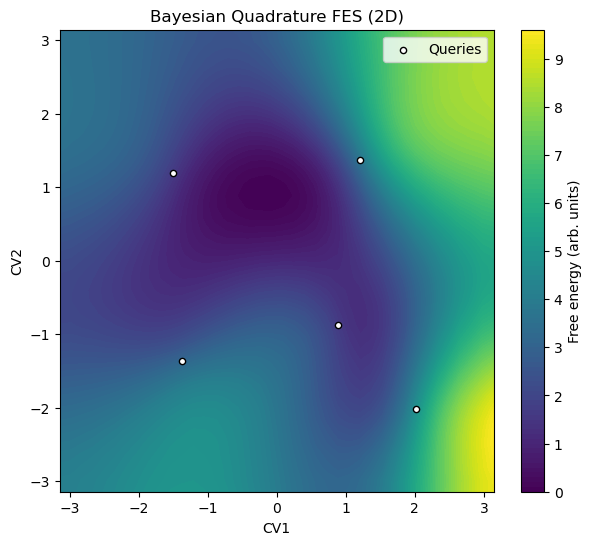

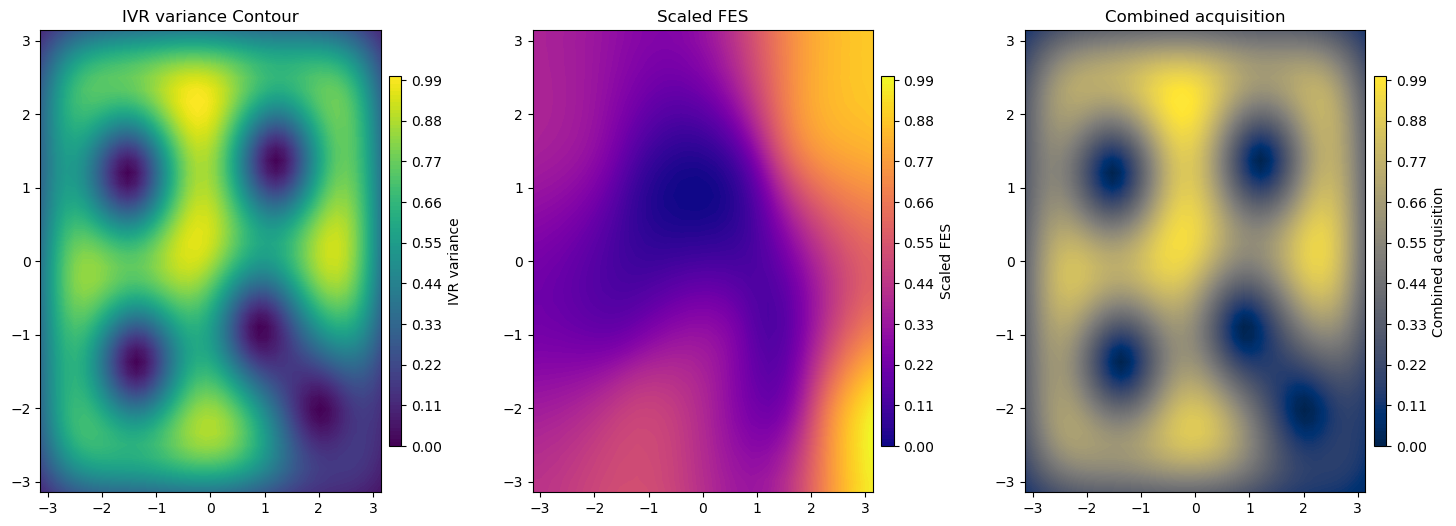


--- Step 4/5 ---
Selected next point: [-0.24166097  2.17494876]
# Integrating             - Simpson's rule 
# Integration error:        3.43



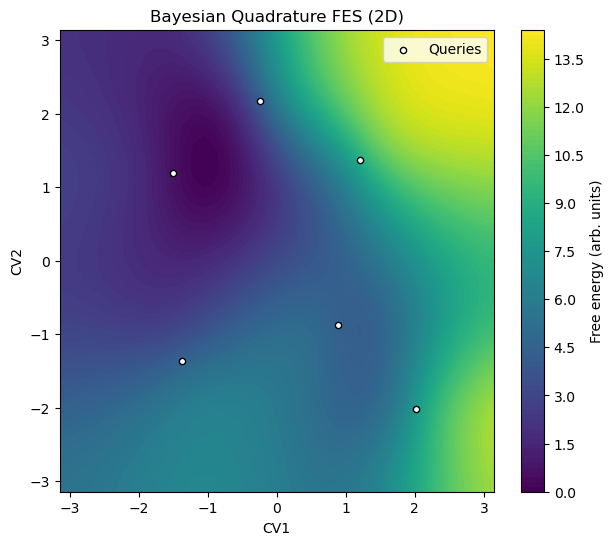

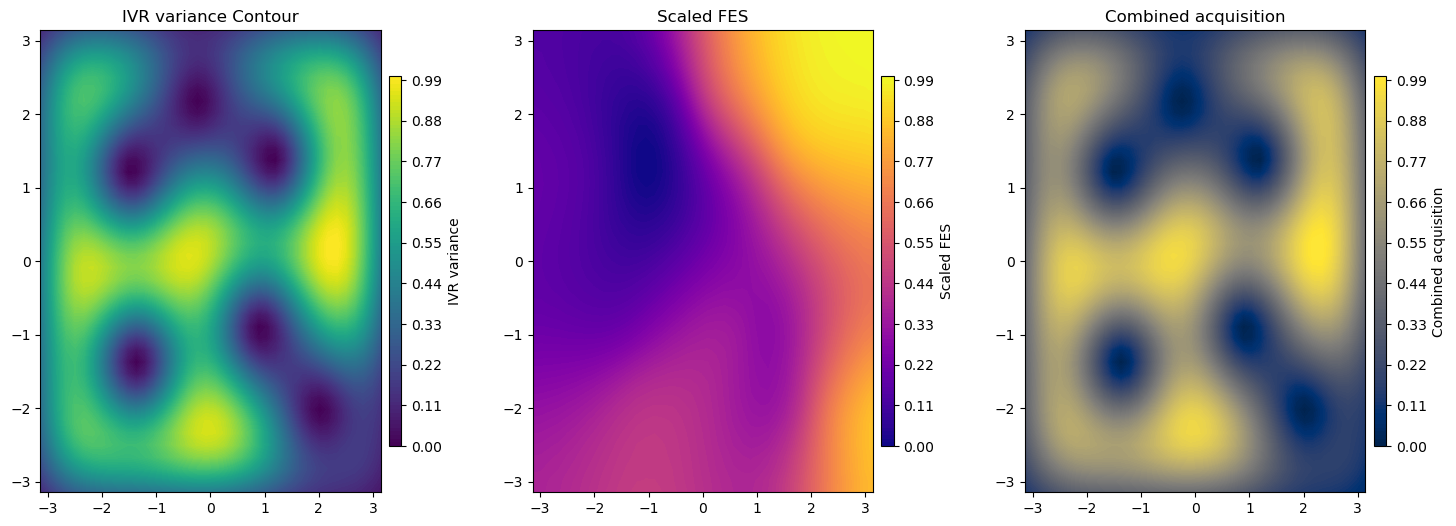


--- Step 5/5 ---
Selected next point: [2.33605608 0.24166097]
# Integrating             - Simpson's rule 
# Integration error:        2.95



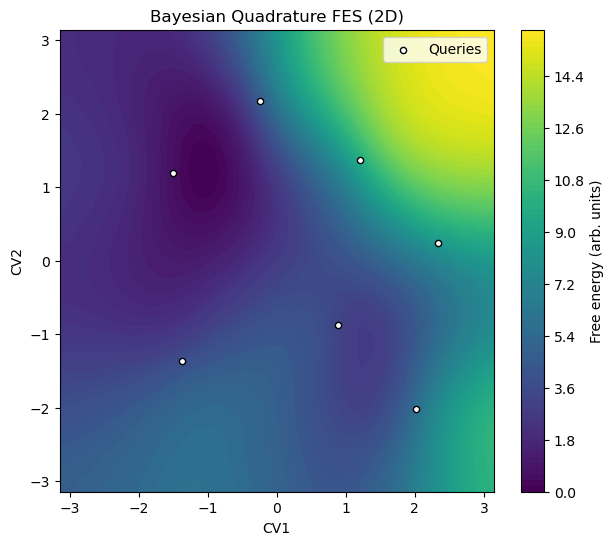

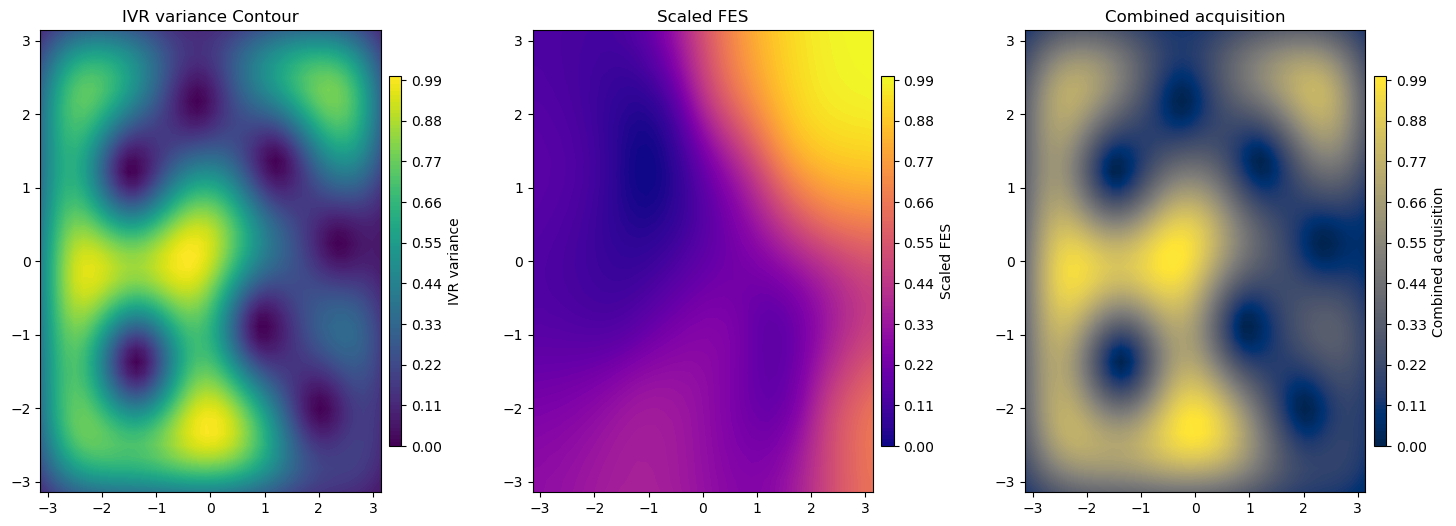

Final FES shape: (40, 40)


In [5]:
# --- Settings: change these! ---
n_steps    = 5
weight_fes = 0.0
# --------------------------------

runner = BayesianQuadratureRunner(system, config)
runner.initialize(initial_points)

for i in range(n_steps):
    print(f"\n--- Step {i+1}/{n_steps} ---")
    runner.run_one_query(weight_fes=weight_fes)
    runner.plot_fes(show=True)
    runner.plot_acq(show=True, full=True)

print("Final FES shape:", runner.current_fes_2d.shape)

**Questions:**
- How do the sampling locations compare to notebook 1 (BO)?
- Does BUQ sample near the force zero crossings, or elsewhere?
- What changes when you increase `weight_fes`?

## 5. Effect of kernel and lengthscale

The kernel controls the GP's assumptions about the smoothness of the force.

- **Small lengthscale**: GP varies quickly -- can fit sharp features, but needs more points to cover the domain
- **Large lengthscale**: GP varies slowly -- smooth FES, may miss sharp features
- **RBF**: infinitely smooth (strong assumption)
- **Matern12/32/52**: less smooth, more realistic for MD forces, where Matern12 is really for sharp, rugged derivatives, while Matern52 is smoother

In 2D you can also use **anisotropic (ARD) lengthscales**, e.g. `[0.6, 1.2]`,
if the force varies at different rates along phi and psi.

### TODO: run each cell and compare the FES reconstructions

In [6]:
# Helper -- no need to change this
def run_buq(kernel_type, lengthscale, noise=1e-6, n_queries=8,
            weight_acq=1.0, weight_fes=0.0, title=""):
    """Run a full BUQ loop and return the runner."""
    cfg = BQConfig(
        kernel_type=kernel_type,
        lengthscale=np.atleast_1d(lengthscale),
        noise=noise,
        variance=1.0,
        acq_function="IVR",
        grid_size_2d=(40, 40),
        use_mini=True,
        fast_mini=True,
    )
    r = BayesianQuadratureRunner(system, cfg)
    r.initialize(np.array([[-1.507964474, 1.193805208 ],  [0.879645943, -0.879645943]])) 
    r.run(n_queries=n_queries, weight_acq=weight_acq, weight_fes=weight_fes)
    print(f"\n{title}")
    r.plot_derivatives(show=True)
    r.plot_fes(show=True)
    return r

Running initial simulation at x = [-1.50796447  1.19380521]
Running initial simulation at x = [ 0.87964594 -0.87964594]
# Integrating             - Simpson's rule 
# Integration error:        0.02


=== Adaptive iteration 1 / 8 ===
Selected next point: [0.72498292 1.20830487]

=== Adaptive iteration 2 / 8 ===
Selected next point: [-1.20830487 -1.04719755]

=== Adaptive iteration 3 / 8 ===
Selected next point: [-0.40276829  0.24166097]

=== Adaptive iteration 4 / 8 ===
Selected next point: [1.85273413 0.24166097]

=== Adaptive iteration 5 / 8 ===
Selected next point: [-0.08055366 -1.85273413]

=== Adaptive iteration 6 / 8 ===
Selected next point: [ 1.85273413 -1.85273413]

=== Adaptive iteration 7 / 8 ===
Selected next point: [1.85273413 1.85273413]

=== Adaptive iteration 8 / 8 ===
Selected next point: [-0.40276829  1.85273413]
# Integrating             - Simpson's rule 
# Integration error:        0.40


Matern32, lengthscale=0.1


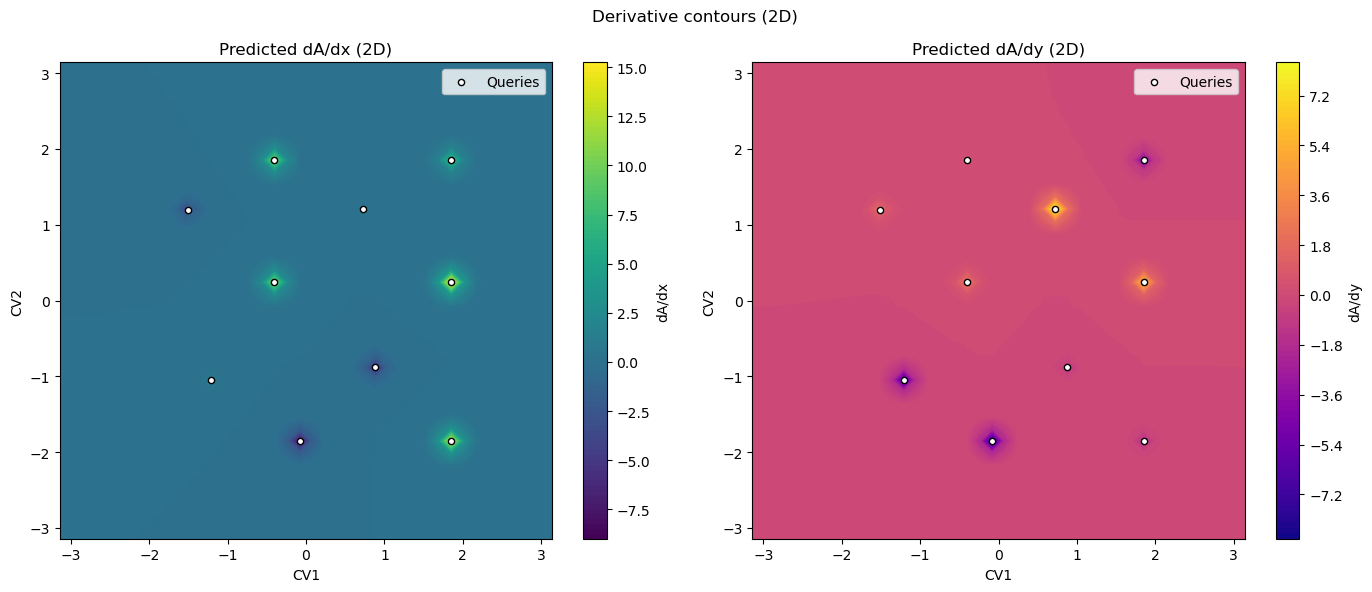

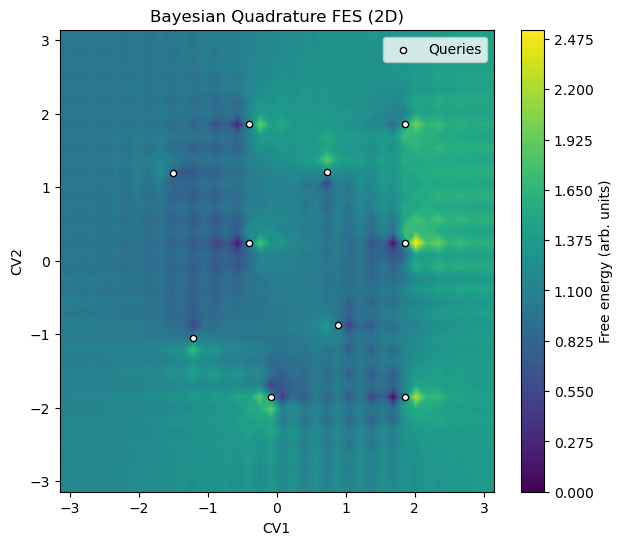

In [7]:
r_short   = run_buq("Matern32", lengthscale=[0.1, 0.1], title="Matern32, lengthscale=0.1")

Running initial simulation at x = [-1.50796447  1.19380521]
Running initial simulation at x = [ 0.87964594 -0.87964594]
# Integrating             - Simpson's rule 
# Integration error:        0.57


=== Adaptive iteration 1 / 8 ===
Selected next point: [1.20830487 1.36941218]

=== Adaptive iteration 2 / 8 ===
Selected next point: [-1.36941218 -1.36941218]

=== Adaptive iteration 3 / 8 ===
Selected next point: [ 2.01384144 -2.01384144]

=== Adaptive iteration 4 / 8 ===
Selected next point: [-0.24166097  2.17494876]

=== Adaptive iteration 5 / 8 ===
Selected next point: [2.33605608 0.24166097]

=== Adaptive iteration 6 / 8 ===
Selected next point: [-0.40276829  0.08055366]

=== Adaptive iteration 7 / 8 ===
Selected next point: [-0.08055366 -2.33605608]

=== Adaptive iteration 8 / 8 ===
Selected next point: [-2.33605608 -0.24166097]
# Integrating             - Simpson's rule 
# Integration error:        5.29


Matern32, lengthscale=0.75


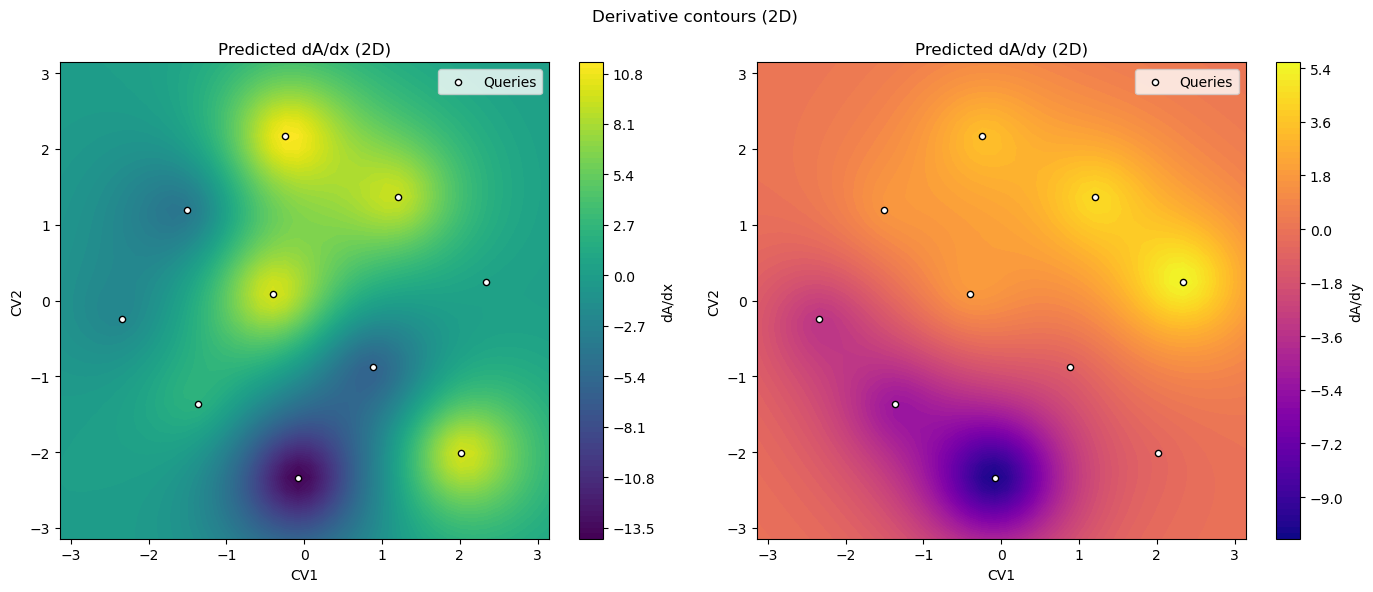

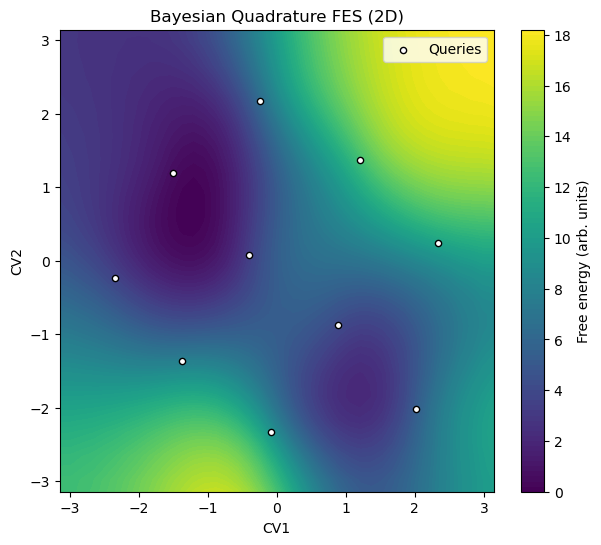

In [8]:
r_default = run_buq("Matern32", lengthscale=[0.75, 0.75], title="Matern32, lengthscale=0.75")

Running initial simulation at x = [-1.50796447  1.19380521]
Running initial simulation at x = [ 0.87964594 -0.87964594]
# Integrating             - Simpson's rule 
# Integration error:        0.94


=== Adaptive iteration 1 / 8 ===
Selected next point: [1.69162681 1.85273413]

=== Adaptive iteration 2 / 8 ===
Selected next point: [-1.69162681 -1.85273413]

=== Adaptive iteration 3 / 8 ===
Selected next point: [ 2.17494876 -2.01384144]

=== Adaptive iteration 4 / 8 ===
Selected next point: [-0.40276829  2.33605608]

=== Adaptive iteration 5 / 8 ===
Selected next point: [-2.17494876 -0.08055366]

=== Adaptive iteration 6 / 8 ===
Selected next point: [2.17494876 0.40276829]

=== Adaptive iteration 7 / 8 ===
Selected next point: [-0.08055366 -2.17494876]

=== Adaptive iteration 8 / 8 ===
Selected next point: [-2.49716339  2.33605608]
# Integrating             - Simpson's rule 
# Integration error:        11.90


Matern32, lengthscale=2.0


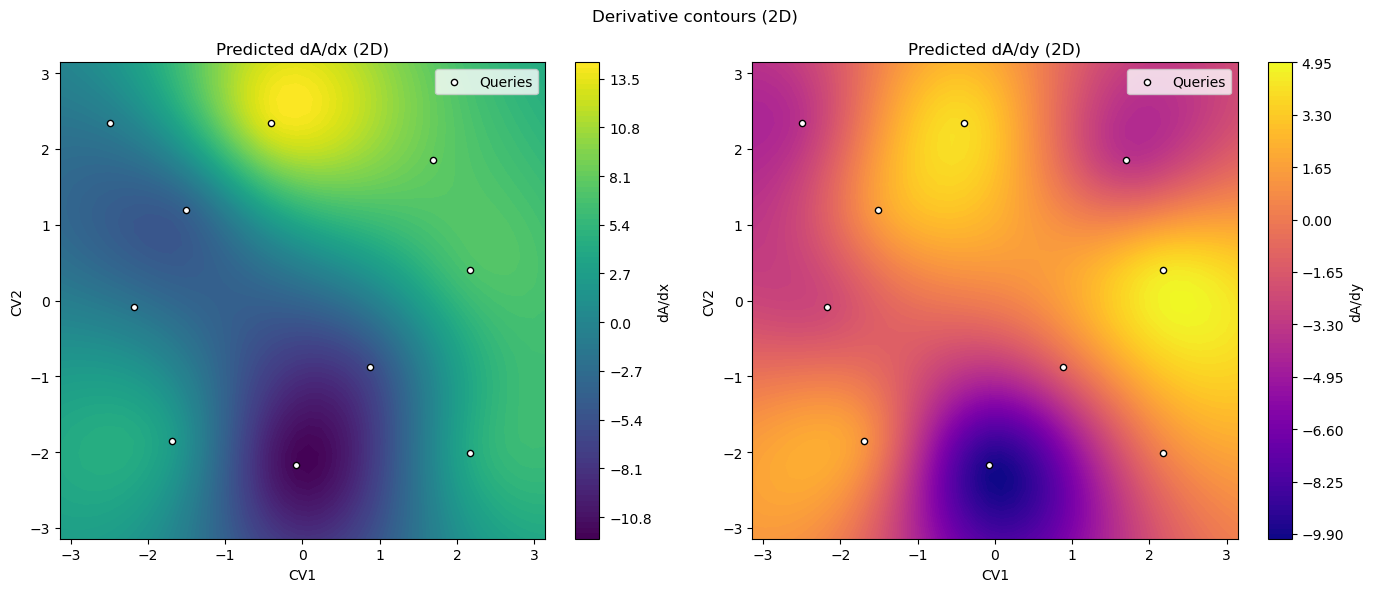

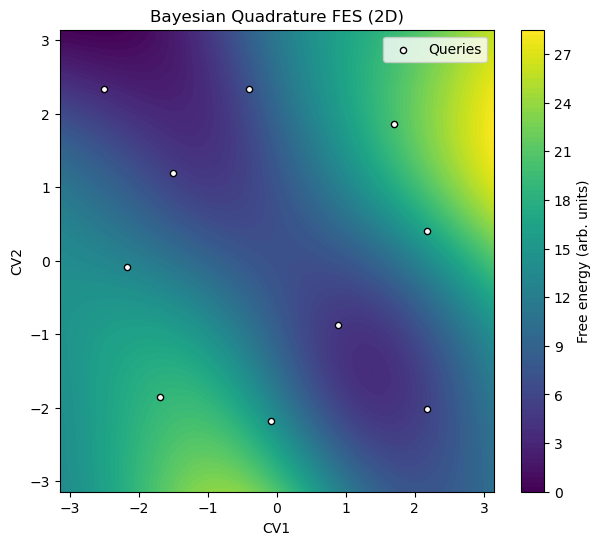

In [9]:
r_long    = run_buq("Matern32", lengthscale=[2.0, 2.0], title="Matern32, lengthscale=2.0")

Running initial simulation at x = [-1.50796447  1.19380521]
Running initial simulation at x = [ 0.87964594 -0.87964594]
# Integrating             - Simpson's rule 
# Integration error:        0.43


=== Adaptive iteration 1 / 8 ===
Selected next point: [2.01384144 0.88609024]

=== Adaptive iteration 2 / 8 ===
Selected next point: [-0.72498292 -1.20830487]

=== Adaptive iteration 3 / 8 ===
Selected next point: [-2.33605608 -1.04719755]

=== Adaptive iteration 4 / 8 ===
Selected next point: [0.24166097 1.5305195 ]

=== Adaptive iteration 5 / 8 ===
Selected next point: [ 2.33605608 -1.5305195 ]

=== Adaptive iteration 6 / 8 ===
Selected next point: [-2.49716339  1.69162681]

=== Adaptive iteration 7 / 8 ===
Selected next point: [1.36941218 2.17494876]

=== Adaptive iteration 8 / 8 ===
Selected next point: [ 0.24166097 -2.17494876]
# Integrating             - Simpson's rule 
# Integration error:        3.97


Matern32, ARD lengthscale=[0.6, 1.2]


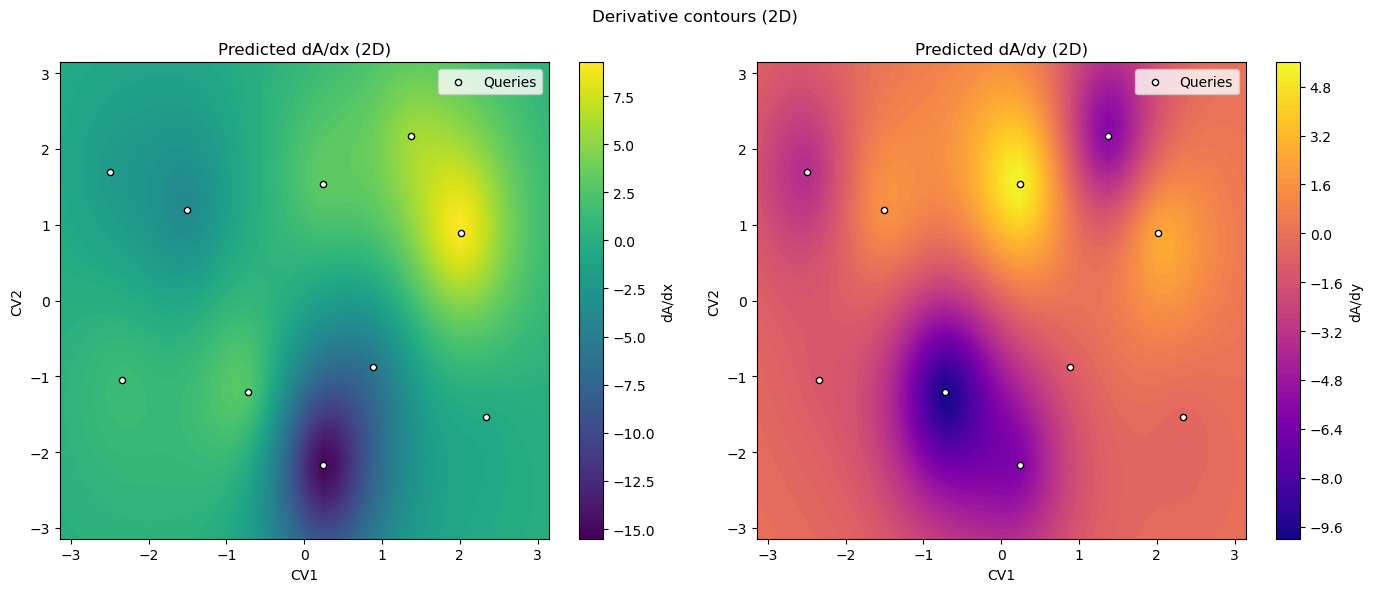

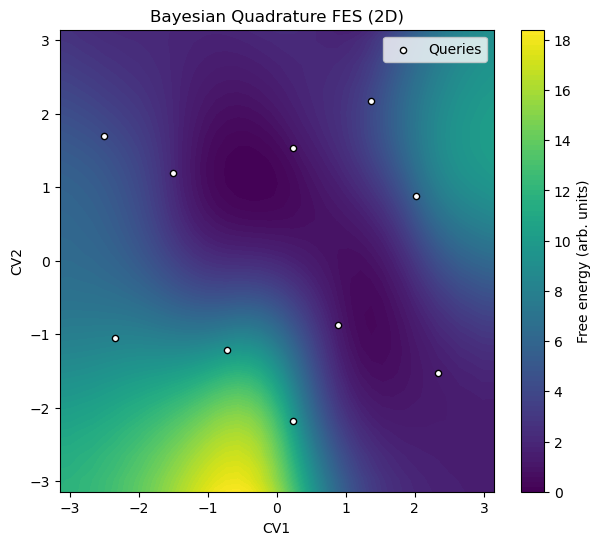

In [10]:
r_ard     = run_buq("Matern32", lengthscale=[0.6, 1.2], title="Matern32, ARD lengthscale=[0.6, 1.2]")

In [ ]:
r_rbf     = run_buq("RBF",      lengthscale=[0.6, 0.6], title="RBF, lengthscale=0.6")

**Questions:**
- Which kernel/lengthscale gives the best FES reconstruction?
- With a short lengthscale: does the GP overfit the initial points?
- With a long lengthscale: does the FES miss any features?
- Does using ARD lengthscales improve the reconstruction?
- Why might RBF be a poor choice for MD force data?

## 6. Acquisition functions: IVR vs US vs MI

So far we used **IVR** (Integral Variance Reduction), which directly minimizes
the variance of the integral estimate.

Two alternatives are available:
- **US** (Uncertainty Sampling): samples where GP variance is highest
- **MI** (Mutual Information): samples where information gain is highest

IVR is the most principled choice for BUQ, but the others can be useful
for comparison. Note, in vanilla BQ, both IVR and MI are identical in the sense that their armax that yields 
 is identical, i.e., the location of their global optimum is the same. This can be seen since IVR is a transformation of MI by the strictly monotonic function 
. Si

### TODO: run each cell and compare sampling patterns

In [11]:
# Note: to use a different acquisition, change acq_function in BQConfig inside run_buq,
# or copy the helper and modify it:

def run_buq_acq(acq_function, n_queries=20, weight_acq=1.0, weight_fes=0.0, title=""):
    cfg = BQConfig(
        kernel_type="Matern32",
        lengthscale=np.array([0.75, 0.75]),
        noise=1e-6,
        variance=1.0,
        acq_function=acq_function,
        grid_size_2d=(40, 40),
        use_mini=True,
        fast_mini=True,
    )
    r = BayesianQuadratureRunner(system, cfg)
    r.initialize(np.array([[-1.507964474, 1.193805208 ],  [0.879645943, -0.879645943]]))
    r.run(n_queries=n_queries, weight_acq=weight_acq, weight_fes=weight_fes)
    print(f"\n{title}")
    r.plot_fes(show=True)
    r.plot_acq(show=True, full=True)
    return r

Running initial simulation at x = [-1.50796447  1.19380521]
Running initial simulation at x = [ 0.87964594 -0.87964594]
# Integrating             - Simpson's rule 
# Integration error:        0.57


=== Adaptive iteration 1 / 20 ===
Selected next point: [1.20830487 1.36941218]

=== Adaptive iteration 2 / 20 ===
Selected next point: [-1.36941218 -1.36941218]

=== Adaptive iteration 3 / 20 ===
Selected next point: [ 2.01384144 -2.01384144]

=== Adaptive iteration 4 / 20 ===
Selected next point: [-0.24166097  2.17494876]

=== Adaptive iteration 5 / 20 ===
Selected next point: [2.33605608 0.24166097]

=== Adaptive iteration 6 / 20 ===
Selected next point: [-0.40276829  0.08055366]

=== Adaptive iteration 7 / 20 ===
Selected next point: [-0.08055366 -2.33605608]

=== Adaptive iteration 8 / 20 ===
Selected next point: [-2.33605608 -0.24166097]

=== Adaptive iteration 9 / 20 ===
Selected next point: [2.17494876 2.33605608]

=== Adaptive iteration 10 / 20 ===
Selected next point: [-2.17494876 

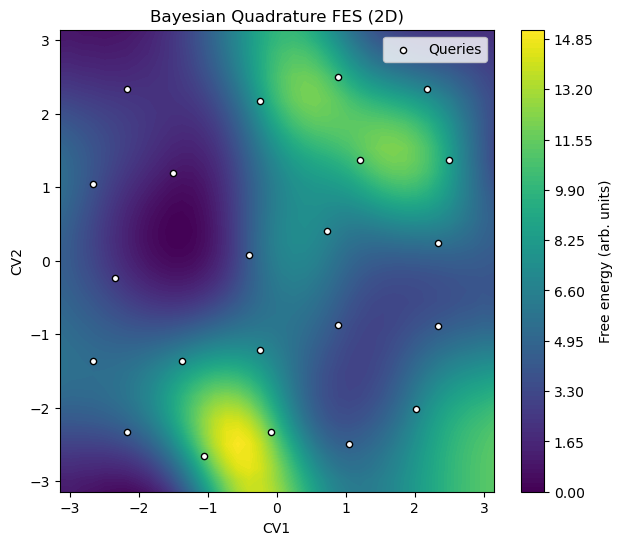

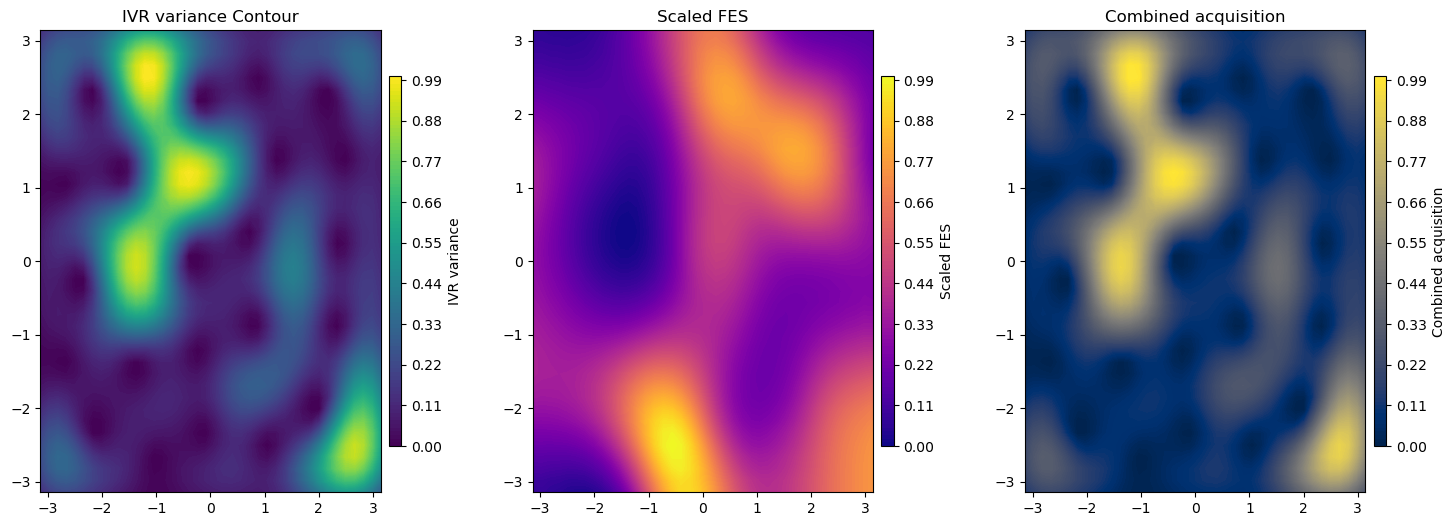

In [13]:
r_ivr = run_buq_acq("IVR",title="IVR")

Running initial simulation at x = [-1.50796447  1.19380521]
Running initial simulation at x = [ 0.87964594 -0.87964594]
# Integrating             - Simpson's rule 
# Integration error:        0.57


=== Adaptive iteration 1 / 20 ===
Selected next point: [3.14159265 3.14159265]

=== Adaptive iteration 2 / 20 ===
Selected next point: [-3.14159265 -3.14159265]

=== Adaptive iteration 3 / 20 ===
Selected next point: [ 3.14159265 -3.14159265]

=== Adaptive iteration 4 / 20 ===
Selected next point: [0.40276829 3.14159265]

=== Adaptive iteration 5 / 20 ===
Selected next point: [-3.14159265  3.14159265]

=== Adaptive iteration 6 / 20 ===
Selected next point: [-0.40276829 -3.14159265]

=== Adaptive iteration 7 / 20 ===
Selected next point: [3.14159265 0.40276829]

=== Adaptive iteration 8 / 20 ===
Selected next point: [-3.14159265 -0.5638756 ]

=== Adaptive iteration 9 / 20 ===
Selected next point: [1.04719755 1.20830487]

=== Adaptive iteration 10 / 20 ===
Selected next point: [-1.20830487 -1

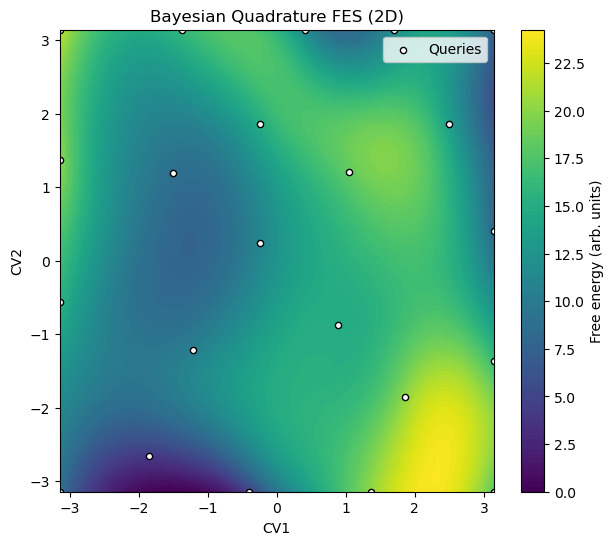

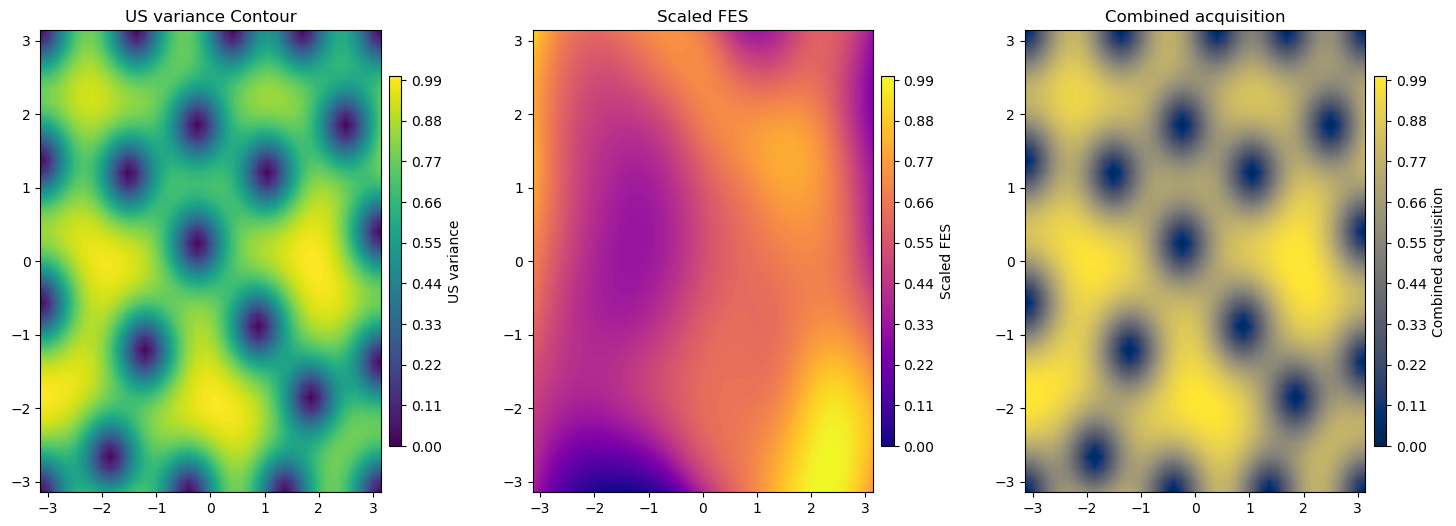

In [12]:
r_us = run_buq_acq("US", title="Uncertainty Sampling")

Running initial simulation at x = [-1.50796447  1.19380521]
Running initial simulation at x = [ 0.87964594 -0.87964594]
# Integrating             - Simpson's rule 
# Integration error:        0.57


=== Adaptive iteration 1 / 20 ===
Selected next point: [1.20830487 1.36941218]

=== Adaptive iteration 2 / 20 ===
Selected next point: [-1.36941218 -1.36941218]

=== Adaptive iteration 3 / 20 ===
Selected next point: [ 2.01384144 -2.01384144]

=== Adaptive iteration 4 / 20 ===
Selected next point: [-0.24166097  2.17494876]

=== Adaptive iteration 5 / 20 ===
Selected next point: [2.33605608 0.24166097]

=== Adaptive iteration 6 / 20 ===
Selected next point: [-0.40276829  0.08055366]

=== Adaptive iteration 7 / 20 ===
Selected next point: [-0.08055366 -2.33605608]

=== Adaptive iteration 8 / 20 ===
Selected next point: [-2.33605608 -0.24166097]

=== Adaptive iteration 9 / 20 ===
Selected next point: [2.17494876 2.33605608]

=== Adaptive iteration 10 / 20 ===
Selected next point: [-2.17494876 

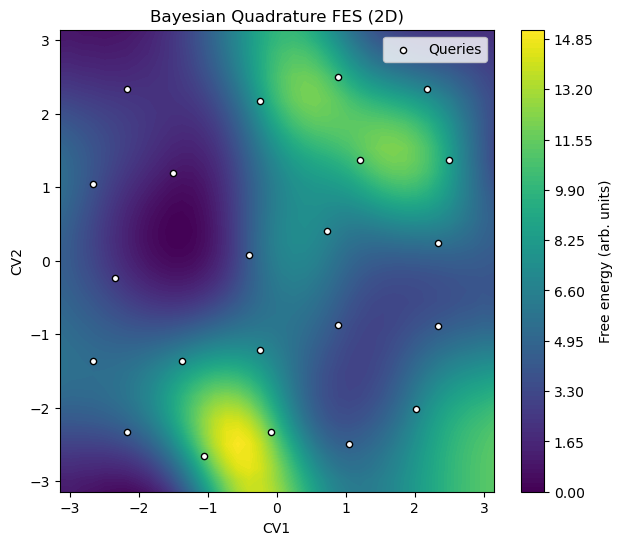

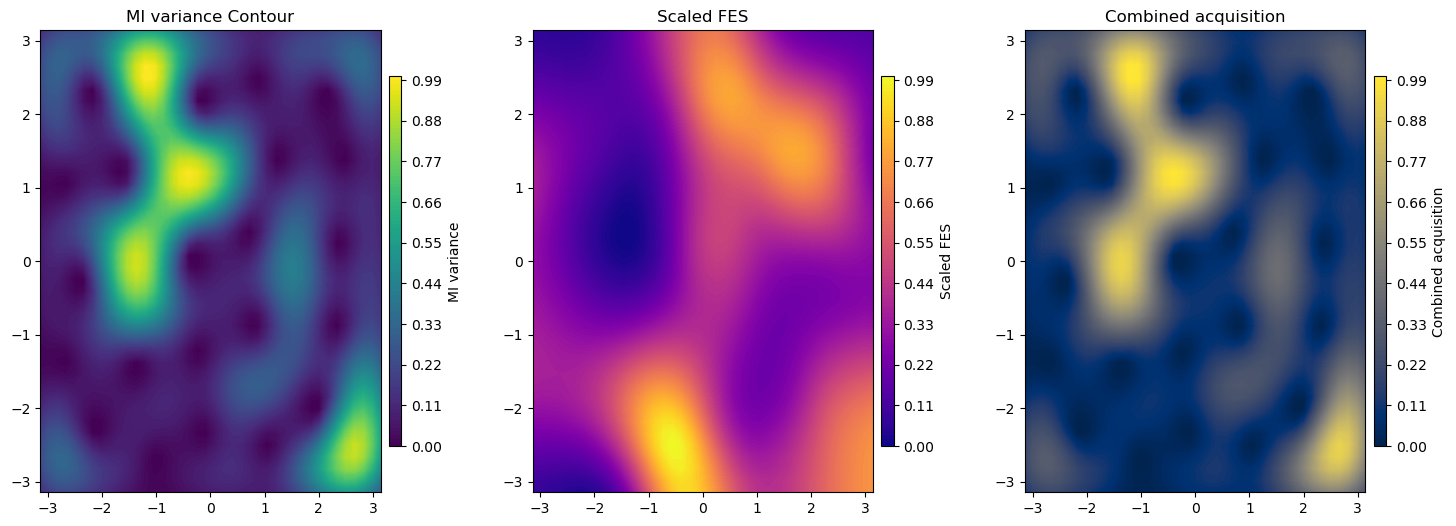

In [14]:
r_mi = run_buq_acq("MI", title="Mutual Information")

**Questions:**
- Do US and MI sample in different locations than IVR?
- Which gives the best FES reconstruction after 8 queries?
- Why is IVR the most natural choice for free energy estimation?

## Summary

| | Notebook 1: BO | Notebook 2: BUQ |
|---|---|---|
| **Objective** | Find zero of force | Reconstruct full FES |
| **GP models** | \|force(phi, psi)\| | force(phi, psi) directly |
| **Acquisition** | EI / PI / LCB | IVR / US / MI |
| **Sampling** | Clusters near minimum | Spreads across domain |
| **Output** | Best (phi, psi) found | F(phi, psi) with error bars |

BUQ is the principled approach when you need the **full free energy surface**
and want to know **how uncertain** your estimate is -- which is exactly what
matters in enhanced sampling MD.